## Import Dataset and Install Library

In [ ]:
!pip install autogluon

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For time series
from typing import List
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

In [2]:
def download_kaggle(kaggle_command="kaggle competitions download -c liver-fibrosis-severity-prediction"):

  # Get Kaggle Key
  kaggle_username = userdata.get("KAGGLE_USER")
  kaggle_key = userdata.get("KAGGLE_KEY")
  if not kaggle_username or not kaggle_key:
      print("Error: Kaggle_USERNAME or Kaggle_KEY not found in Colab Secrets.")
      return

  # Write the credentials to ~/.kaggle/kaggle.json
  kaggle_dir = os.path.expanduser("~/.kaggle")
  os.makedirs(kaggle_dir, exist_ok=True)

  # Create JSON
  kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")
  with open(kaggle_json_path, "w") as f:
      f.write(f'{{"username":"{kaggle_username}","key":"{kaggle_key}"}}')
  os.chmod(kaggle_json_path, 0o600)

  try:
      os.system(kaggle_command)
      print("\n--- Download complete! ---")
      os.system("ls -la")
      os.system("unzip -o '*.zip' && rm -f *.zip")
      os.system("ls -la")

  except Exception as e:
      print(f"An error occurred during download: {e}")

In [3]:
download_kaggle(
    "kaggle competitions download -c individual-test-chest-disease-detection"
)


--- Download complete! ---


## Download ResNet50 Feature Extraction


In [7]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import pandas as pd
import os

In [8]:
class ImageFeatureExtractor:

  def __init__(self, model_name='resnet18', pretrained=True, layer_to_extract='avgpool'):
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    self.model = self._load_model(model_name, pretrained)
    self.model.eval()
    self.model.to(self.device)
    self.layer_to_extract = layer_to_extract
    self.features = None
    self._register_hook()
    self.transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])


  def _load_model(self, model_name, pretrained):

    if model_name == 'resnet18':
        model = models.resnet18(pretrained=pretrained)

    elif model_name == 'resnet50':
        model = models.resnet50(pretrained=pretrained)

    elif model_name == 'vgg16':
        model = models.vgg16(pretrained=pretrained)

    elif model_name == 'alexnet':
        model = models.alexnet(pretrained=pretrained)

    else:
        raise ValueError(f"Model '{model_name}' not supported. Choose from 'resnet18', 'resnet50', 'vgg16', 'alexnet'.")

    # Remove the final classification layer
    if hasattr(model, 'fc'): # For ResNet, AlexNet
        model.fc = torch.nn.Identity()

    elif hasattr(model, 'classifier') and isinstance(model.classifier, torch.nn.modules.container.Sequential): # For VGG, AlexNet
        # Keep all but the last layer (which is the classifier)
        model.classifier = torch.nn.Sequential(*list(model.classifier.children())[:-1])

    return model



  def _hook_fn(self, module, input, output):
    """Hook function to capture the output of the specified layer."""
    self.features = output.detach().squeeze().cpu()



  def _register_hook(self):
    """Registers a forward hook to the specified layer of the model."""
    target_layer = None
    if self.layer_to_extract == 'avgpool' and hasattr(self.model, 'avgpool'):
        target_layer = self.model.avgpool

    elif self.layer_to_extract == 'fc' and hasattr(self.model, 'fc'): # Before Identity for ResNet
      # If fc is Identity, we might want features from the layer before it (avgpool)
      # This logic needs to be careful depending on the model's architecture
      if isinstance(self.model.fc, torch.nn.Identity):
          print("Warning: 'fc' layer is Identity. Extracting from 'avgpool' instead for ResNet-like models.")
          target_layer = self.model.avgpool

      else:
          target_layer = self.model.fc

    elif self.layer_to_extract == 'classifier' and hasattr(self.model, 'classifier'):
      # For models like VGG, AlexNet, the classifier is a Sequential.
      # We want the output of the layer *before* the final classification.
      if isinstance(self.model.classifier, torch.nn.modules.container.Sequential) and len(self.model.classifier) > 1:
          target_layer = self.model.classifier[-1] # This would be the last layer before Identity was set
          if isinstance(target_layer, torch.nn.Identity): # If classifier was replaced with Identity
              print("Warning: Classifier last layer is Identity. Trying to get previous layer if available.")
              if len(self.model.classifier) > 2:
                  target_layer = self.model.classifier[-2] # Get the layer before the last one
              else:
                  raise ValueError(f"Could not find a suitable layer to extract from 'classifier' for {self.layer_to_extract}.")
      else:
          target_layer = self.model.classifier

    if target_layer is None:
        raise ValueError(f"Layer '{self.layer_to_extract}' not found or suitable for extraction in the selected model.")

    target_layer.register_forward_hook(self._hook_fn)
    print(f"Hook registered on layer: {self.layer_to_extract}")



  def extract(self, image_path):
    """
    Extracts features from a single image.

    Args:
        image_path (str): Path to the image file.

    Returns:
        np.ndarray: A 1D numpy array representing the extracted features (tabular data).
    """
    img = Image.open(image_path).convert('RGB')
    img_tensor = self.transform(img).unsqueeze(0).to(self.device)

    with torch.no_grad():
        _ = self.model(img_tensor) # Forward pass will trigger the hook

    if self.features is None:
        raise RuntimeError("Features were not captured. Check layer_to_extract and model architecture.")

    # Reset features for the next extraction
    features_to_return = self.features.numpy()
    self.features = None
    return features_to_return

In [9]:
# # Initialize the feature extractor using ResNet18 -> can choose 'resnet50', 'vgg16', 'alexnet' and 'avgpool' or 'fc' as layer
# extractor = ImageFeatureExtractor(model_name='resnet50', pretrained=True, layer_to_extract='avgpool')

# # Loop the folder image
# DIRECTORY = "/content/images/images"

# list_for_df = []

# # Iterate over files in directory
# for name in os.listdir(DIRECTORY):

#   image_file = os.path.join(DIRECTORY, name)
#   features = extractor.extract(image_file)

#   list_for_df.append(features)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 215MB/s]


Hook registered on layer: avgpool


In [10]:
# # Get name from files
# list_name = []

# for name in os.listdir(DIRECTORY):
#   list_name.append(name)

In [18]:
# df_features = pd.DataFrame(list_for_df)
# df_features

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0.169475,1.198240,0.758869,0.146843,0.183705,0.264467,0.177276,0.309828,0.781875,0.205465,...,0.104067,0.174813,0.002343,0.493856,0.675112,0.143374,0.061628,0.119768,1.703513,0.524009
1,0.317365,1.151674,1.683811,0.130840,0.189583,0.354886,0.167595,0.289402,0.655502,0.334941,...,0.395034,0.095766,0.111811,0.435649,0.455221,0.121458,0.038510,0.148581,0.650255,0.655780
2,0.530452,1.007566,0.994446,0.326152,0.265369,0.404544,0.486098,0.556744,0.289599,0.744450,...,0.014635,0.079834,0.019210,0.278412,0.131504,0.032689,0.023186,0.320815,1.030829,0.611350
3,0.218888,0.593850,1.266144,0.268101,0.102984,0.342573,0.397694,0.253287,0.481984,0.321481,...,0.314595,0.077931,0.300875,0.409790,0.110698,0.078550,0.001438,0.227047,1.227130,0.684267
4,0.396049,1.306760,0.610523,0.339749,0.221261,1.021739,0.215290,0.335714,0.415377,0.504228,...,0.147924,0.032922,0.151746,0.547517,0.136947,0.175009,0.152438,0.103320,1.018894,0.225803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12464,0.178753,0.401965,1.323530,0.116737,0.248798,0.766191,0.415434,0.611802,0.515525,0.330202,...,0.089581,0.063276,0.009709,0.491349,0.563827,0.161009,0.144599,0.193658,0.812770,0.224159
12465,0.159734,0.914618,1.155981,0.130813,0.045849,0.405936,0.449306,0.671927,0.432675,0.244324,...,0.183466,0.099772,0.242604,0.334817,0.453395,0.087509,0.106641,0.534820,0.941390,0.064542
12466,0.288613,0.745333,0.796572,0.192346,0.208318,0.636778,0.190400,0.154660,0.688696,0.259124,...,0.183949,0.209894,0.051364,0.262905,0.484528,0.067461,0.000000,0.261877,0.881330,0.930446
12467,0.107857,0.695928,0.874922,0.128281,0.195997,0.029883,0.523705,0.462669,0.990470,0.144952,...,0.332079,0.028589,0.147845,0.498133,0.245645,0.191303,0.168726,0.035134,2.202262,0.402003


In [19]:
# df_names = pd.DataFrame(list_name)
# df_names

,0
0,cxr10221.jpg
1,cxr06232.jpg
2,cxr00912.jpg
3,cxr08358.jpg
4,cxr11141.jpg
...,...
12464,cxr10657.jpg
12465,cxr03981.jpg
12466,cxr00156.jpg
12467,cxr02781.jpg


In [21]:
df_names.columns

RangeIndex(start=0, stop=1, step=1)

In [22]:
df_names.columns = ['image_name']
print(df_names)

         image_name
0      cxr10221.jpg
1      cxr06232.jpg
2      cxr00912.jpg
3      cxr08358.jpg
4      cxr11141.jpg
...             ...
12464  cxr10657.jpg
12465  cxr03981.jpg
12466  cxr00156.jpg
12467  cxr02781.jpg
12468  cxr06373.jpg

[12469 rows x 1 columns]


In [23]:
df_names

,image_name
0,cxr10221.jpg
1,cxr06232.jpg
2,cxr00912.jpg
3,cxr08358.jpg
4,cxr11141.jpg
...,...
12464,cxr10657.jpg
12465,cxr03981.jpg
12466,cxr00156.jpg
12467,cxr02781.jpg


In [24]:
# Left join concat
df_images = pd.concat([df_names, df_features], axis=1)
df_images

,image_name,0,1,2,3,4,5,6,7,8,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,cxr10221.jpg,0.169475,1.198240,0.758869,0.146843,0.183705,0.264467,0.177276,0.309828,0.781875,...,0.104067,0.174813,0.002343,0.493856,0.675112,0.143374,0.061628,0.119768,1.703513,0.524009
1,cxr06232.jpg,0.317365,1.151674,1.683811,0.130840,0.189583,0.354886,0.167595,0.289402,0.655502,...,0.395034,0.095766,0.111811,0.435649,0.455221,0.121458,0.038510,0.148581,0.650255,0.655780
2,cxr00912.jpg,0.530452,1.007566,0.994446,0.326152,0.265369,0.404544,0.486098,0.556744,0.289599,...,0.014635,0.079834,0.019210,0.278412,0.131504,0.032689,0.023186,0.320815,1.030829,0.611350
3,cxr08358.jpg,0.218888,0.593850,1.266144,0.268101,0.102984,0.342573,0.397694,0.253287,0.481984,...,0.314595,0.077931,0.300875,0.409790,0.110698,0.078550,0.001438,0.227047,1.227130,0.684267
4,cxr11141.jpg,0.396049,1.306760,0.610523,0.339749,0.221261,1.021739,0.215290,0.335714,0.415377,...,0.147924,0.032922,0.151746,0.547517,0.136947,0.175009,0.152438,0.103320,1.018894,0.225803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12464,cxr10657.jpg,0.178753,0.401965,1.323530,0.116737,0.248798,0.766191,0.415434,0.611802,0.515525,...,0.089581,0.063276,0.009709,0.491349,0.563827,0.161009,0.144599,0.193658,0.812770,0.224159
12465,cxr03981.jpg,0.159734,0.914618,1.155981,0.130813,0.045849,0.405936,0.449306,0.671927,0.432675,...,0.183466,0.099772,0.242604,0.334817,0.453395,0.087509,0.106641,0.534820,0.941390,0.064542
12466,cxr00156.jpg,0.288613,0.745333,0.796572,0.192346,0.208318,0.636778,0.190400,0.154660,0.688696,...,0.183949,0.209894,0.051364,0.262905,0.484528,0.067461,0.000000,0.261877,0.881330,0.930446
12467,cxr02781.jpg,0.107857,0.695928,0.874922,0.128281,0.195997,0.029883,0.523705,0.462669,0.990470,...,0.332079,0.028589,0.147845,0.498133,0.245645,0.191303,0.168726,0.035134,2.202262,0.402003


In [150]:
df_images.to_csv("image_extraction_resnet50.csv")

## Manage Data

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For time series
from typing import List
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

In [4]:
df_images = pd.read_csv("/content/image_extraction_resnet50.csv")
df_images

,Unnamed: 0,image_name,0,1,2,3,4,5,6,7,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0,cxr10221.jpg,0.169475,1.198240,0.758869,0.146843,0.183705,0.264467,0.177276,0.309828,...,0.104067,0.174813,0.002343,0.493856,0.675112,0.143374,0.061628,0.119768,1.703513,0.524009
1,1,cxr06232.jpg,0.317365,1.151674,1.683811,0.130840,0.189583,0.354886,0.167595,0.289402,...,0.395034,0.095766,0.111811,0.435649,0.455221,0.121458,0.038510,0.148581,0.650255,0.655780
2,2,cxr00912.jpg,0.530452,1.007566,0.994446,0.326152,0.265369,0.404544,0.486098,0.556744,...,0.014635,0.079834,0.019210,0.278412,0.131504,0.032689,0.023186,0.320815,1.030829,0.611350
3,3,cxr08358.jpg,0.218888,0.593850,1.266144,0.268101,0.102984,0.342573,0.397694,0.253287,...,0.314595,0.077931,0.300875,0.409790,0.110698,0.078550,0.001438,0.227047,1.227130,0.684267
4,4,cxr11141.jpg,0.396049,1.306760,0.610523,0.339749,0.221261,1.021739,0.215290,0.335714,...,0.147924,0.032922,0.151746,0.547517,0.136947,0.175009,0.152438,0.103320,1.018894,0.225803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12464,12464,cxr10657.jpg,0.178753,0.401965,1.323530,0.116737,0.248798,0.766191,0.415434,0.611802,...,0.089581,0.063276,0.009709,0.491349,0.563827,0.161009,0.144599,0.193658,0.812770,0.224159
12465,12465,cxr03981.jpg,0.159734,0.914618,1.155981,0.130813,0.045849,0.405936,0.449306,0.671927,...,0.183466,0.099772,0.242604,0.334817,0.453395,0.087509,0.106641,0.534820,0.941390,0.064542
12466,12466,cxr00156.jpg,0.288613,0.745333,0.796572,0.192347,0.208318,0.636778,0.190400,0.154660,...,0.183949,0.209894,0.051364,0.262905,0.484528,0.067461,0.000000,0.261877,0.881331,0.930446
12467,12467,cxr02781.jpg,0.107857,0.695928,0.874922,0.128281,0.195997,0.029883,0.523705,0.462669,...,0.332079,0.028589,0.147845,0.498133,0.245645,0.191303,0.168726,0.035134,2.202262,0.402003


In [7]:
df_images = df_images.drop(
    columns = ["Unnamed: 0"]
)

df_images.columns

Index(['image_name', '0', '1', '2', '3', '4', '5', '6', '7', '8',
       ...
       '2038', '2039', '2040', '2041', '2042', '2043', '2044', '2045', '2046',
       '2047'],
      dtype='object', length=2049)

In [8]:
df_train = pd.read_csv("/content/train.csv")
df_train = df_train.rename(columns={"filename": "image_name"})
df_train

,image_name,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax
0,cxr00004.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,cxr00005.jpg,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,cxr00006.jpg,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,cxr00009.jpg,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,cxr00012.jpg,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9958,cxr12465.jpg,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9959,cxr12466.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9960,cxr12467.jpg,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
9961,cxr12468.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [9]:
df_train.columns

Index(['image_name', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
       'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
       'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia',
       'Pneumothorax'],
      dtype='object')

# Transform Data

In [52]:
df_1 = df_train[["image_name", "Atelectasis"]]
df_2 = df_train[["image_name", "Cardiomegaly"]]
df_3 = df_train[["image_name", "Consolidation"]]
df_4 = df_train[["image_name", "Edema"]]

df_5 = df_train[["image_name", "Enlarged Cardiomediastinum"]]
df_6 = df_train[["image_name", "Fracture"]]
df_7 = df_train[["image_name", "Lung Lesion"]]
df_8 = df_train[["image_name", "Lung Opacity"]]

df_9 = df_train[["image_name", "No Finding"]]
df_10 = df_train[["image_name", "Pleural Effusion"]]
df_11 = df_train[["image_name", "Pleural Other"]]
df_12 = df_train[["image_name", "Pneumonia"]]
df_13 = df_train[["image_name", "Pneumothorax"]]

In [53]:
df_1 = pd.merge(df_images, df_1, on='image_name', how='inner')
df_2 = pd.merge(df_images, df_2, on='image_name', how='inner')
df_3 = pd.merge(df_images, df_3, on='image_name', how='inner')
df_4 = pd.merge(df_images, df_4, on='image_name', how='inner')
df_5 = pd.merge(df_images, df_5, on='image_name', how='inner')

df_6 = pd.merge(df_images, df_6, on='image_name', how='inner')
df_7 = pd.merge(df_images, df_7, on='image_name', how='inner')
df_8 = pd.merge(df_images, df_8, on='image_name', how='inner')
df_9 = pd.merge(df_images, df_9, on='image_name', how='inner')
df_10 = pd.merge(df_images, df_10, on='image_name', how='inner')


df_11 = pd.merge(df_images, df_11, on='image_name', how='inner')
df_12 = pd.merge(df_images, df_12, on='image_name', how='inner')
df_13 = pd.merge(df_images, df_13, on='image_name', how='inner')

In [54]:
df_1

,image_name,0,1,2,3,4,5,6,7,8,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,Atelectasis
0,cxr10221.jpg,0.169475,1.198240,0.758869,0.146843,0.183705,0.264467,0.177276,0.309828,0.781875,...,0.174813,0.002343,0.493856,0.675112,0.143374,0.061628,0.119768,1.703513,0.524009,0.0
1,cxr06232.jpg,0.317365,1.151674,1.683811,0.130840,0.189583,0.354886,0.167595,0.289402,0.655502,...,0.095766,0.111811,0.435649,0.455221,0.121458,0.038510,0.148581,0.650255,0.655780,0.0
2,cxr08358.jpg,0.218888,0.593850,1.266144,0.268101,0.102984,0.342573,0.397694,0.253287,0.481984,...,0.077931,0.300875,0.409790,0.110698,0.078550,0.001438,0.227047,1.227130,0.684267,1.0
3,cxr11141.jpg,0.396049,1.306760,0.610523,0.339749,0.221261,1.021739,0.215290,0.335714,0.415377,...,0.032922,0.151746,0.547517,0.136947,0.175009,0.152438,0.103320,1.018894,0.225803,1.0
4,cxr08077.jpg,0.422955,0.757582,0.820695,0.179231,0.229025,0.119981,0.251935,0.245643,0.562300,...,0.096020,0.161342,0.223963,0.328342,0.050113,0.018775,0.086191,1.333871,0.705811,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9958,cxr04940.jpg,0.026777,1.203298,1.167574,0.506277,0.362387,0.296274,0.120764,0.385789,0.346862,...,0.001739,0.108403,0.509536,0.076648,0.079348,0.021239,0.238630,0.707739,0.087441,1.0
9959,cxr08552.jpg,0.309001,0.417639,1.238346,0.153801,0.102274,1.562844,0.404007,0.298734,0.745704,...,0.007669,0.032894,0.541596,0.499500,0.151506,0.227835,0.076141,1.927933,0.740944,1.0
9960,cxr11216.jpg,0.314141,0.781196,0.670378,0.045802,0.257681,1.604201,0.218389,0.392016,0.671770,...,0.091282,0.138149,0.282851,0.719007,0.064981,0.133699,0.187000,1.044255,0.757437,0.0
9961,cxr10657.jpg,0.178753,0.401965,1.323530,0.116737,0.248798,0.766191,0.415434,0.611802,0.515525,...,0.063276,0.009709,0.491349,0.563827,0.161009,0.144599,0.193658,0.812770,0.224159,0.0


## Preparing for Classification Model

In [55]:
list_class = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
       'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
       'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia',
       'Pneumothorax']

<Axes: xlabel='Atelectasis', ylabel='count'>

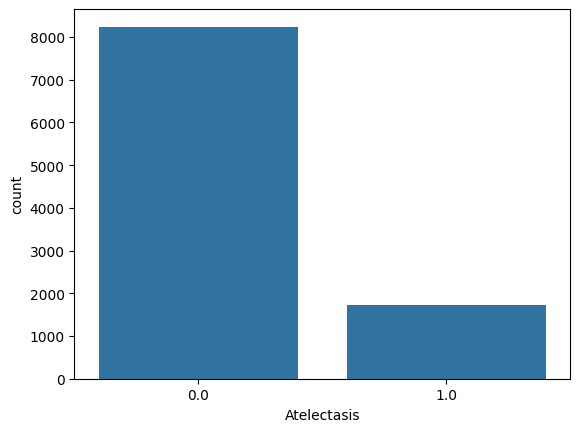

In [56]:
sns.countplot(df_1, x='Atelectasis')

<Axes: xlabel='Cardiomegaly', ylabel='count'>

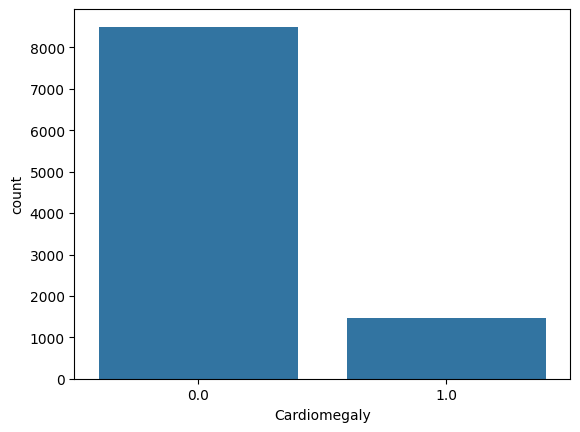

In [57]:
sns.countplot(df_2, x='Cardiomegaly')

## SMOTE Class

In [58]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from collections import Counter
from sklearn.preprocessing import LabelEncoder

# Oversampling the Minority Class using SMOTE
def smote_upsampling(df, target):

  # Define Label Encoder
  le = LabelEncoder()
  le_list = le.fit_transform(df["image_name"])
  print(le_list)
  df = pd.concat([df, pd.DataFrame(le_list)], axis=1)
  df = df.drop(columns=['image_name'])
  df.columns = [*df.columns[:-1], 'image_name']
  print(df.head())
  print(df.info())

  # Assign X, y
  df.columns = df.columns.astype(str)
  X = df.drop(columns=[target], axis=1)
  y = df[target]

  # Calling Model
  smote = SMOTE(sampling_strategy='auto')
  print(f"X : {X}")
  print(f"y : {y}")
  X, y = smote.fit_resample(X, y)

  # Concat to fnial form
  df_final = pd.concat([X, y], axis=1)

  # Inverse the label encoder
  df_final["image_name"] = le.inverse_transform(df_final["image_name"])

  return df_final

In [ ]:
# Oversampling the Minority Class using SMOTE
def smote_upsampling(df, target):

  # Define Label Encoder
  le = LabelEncoder()
  le_list = le.fit_transform(df["image_name"])
  print(le_list)
  df = pd.concat([df, pd.DataFrame(le_list)], axis=1)
  df = df.drop(columns=['image_name'])
  df.columns = [*df.columns[:-1], 'image_name']
  print(df.head())
  print(df.info())

  # Assign X, y
  df.columns = df.columns.astype(str)
  X = df.drop(columns=[target], axis=1)
  y = df[target]

  # Calling Model
  smote = SMOTE(sampling_strategy='auto')
  print(f"X : {X}")
  print(f"y : {y}")
  X, y = smote.fit_resample(X, y)

  # Concat to fnial form
  df_final = pd.concat([X, y], axis=1)

  # Inverse the label encoder
  df_final["image_name"] = le.inverse_transform(df_final["image_name"])

  return df_final

In [59]:
df_1 = smote_upsampling(df_1, "Atelectasis")
df_2 = smote_upsampling(df_2, "Cardiomegaly")
df_3 = smote_upsampling(df_3, "Consolidation")
df_4 = smote_upsampling(df_4, "Edema")

df_5 = smote_upsampling(df_5, "Enlarged Cardiomediastinum")
df_6 = smote_upsampling(df_6, "Fracture")
df_7 = smote_upsampling(df_7, "Lung Lesion")
df_8 = smote_upsampling(df_8, "Lung Opacity")

df_9 = smote_upsampling(df_9, "No Finding")
df_10 = smote_upsampling(df_10, "Pleural Effusion")
df_11 = smote_upsampling(df_11, "Pleural Other")
df_12 = smote_upsampling(df_12, "Pneumonia")
df_13 = smote_upsampling(df_13, "Pneumothorax")

[7716 3742 5856 ... 8709 8151 3880]
          0         1         2         3         4         5         6  \
0  0.169475  1.198240  0.758869  0.146843  0.183705  0.264467  0.177276   
1  0.317365  1.151674  1.683811  0.130840  0.189583  0.354886  0.167595   
2  0.218888  0.593850  1.266144  0.268101  0.102984  0.342573  0.397694   
3  0.396049  1.306760  0.610523  0.339749  0.221261  1.021739  0.215290   
4  0.422955  0.757582  0.820695  0.179231  0.229025  0.119981  0.251935   

          7         8         9  ...      2040      2041      2042      2043  \
0  0.309828  0.781875  0.205465  ...  0.002343  0.493856  0.675112  0.143374   
1  0.289402  0.655502  0.334941  ...  0.111811  0.435649  0.455221  0.121458   
2  0.253287  0.481984  0.321481  ...  0.300875  0.409790  0.110698  0.078550   
3  0.335714  0.415377  0.504228  ...  0.151746  0.547517  0.136947  0.175009   
4  0.245643  0.562300  0.552886  ...  0.161342  0.223963  0.328342  0.050113   

       2044      2045      2046 

In [60]:
df_1

,0,1,2,3,4,5,6,7,8,9,...,2040,2041,2042,2043,2044,2045,2046,2047,image_name,Atelectasis
0,0.169475,1.198240,0.758869,0.146843,0.183705,0.264467,0.177276,0.309828,0.781875,0.205465,...,0.002343,0.493856,0.675112,0.143374,0.061628,0.119768,1.703513,0.524009,cxr10221.jpg,0.0
1,0.317365,1.151674,1.683811,0.130840,0.189583,0.354886,0.167595,0.289402,0.655502,0.334941,...,0.111811,0.435649,0.455221,0.121458,0.038510,0.148581,0.650255,0.655780,cxr06232.jpg,0.0
2,0.218888,0.593850,1.266144,0.268101,0.102984,0.342573,0.397694,0.253287,0.481984,0.321481,...,0.300875,0.409790,0.110698,0.078550,0.001438,0.227047,1.227130,0.684267,cxr08358.jpg,1.0
3,0.396049,1.306760,0.610523,0.339749,0.221261,1.021739,0.215290,0.335714,0.415377,0.504228,...,0.151746,0.547517,0.136947,0.175009,0.152438,0.103320,1.018894,0.225803,cxr11141.jpg,1.0
4,0.422955,0.757582,0.820695,0.179231,0.229025,0.119981,0.251935,0.245643,0.562300,0.552886,...,0.161342,0.223963,0.328342,0.050113,0.018775,0.086191,1.333871,0.705811,cxr08077.jpg,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16479,0.252845,0.616610,1.366014,0.385234,0.134513,0.258377,0.367354,0.160360,0.422869,0.281385,...,0.107802,0.358125,0.188987,0.124813,0.054670,0.116604,0.965677,0.637708,cxr07764.jpg,1.0
16480,0.673028,0.606477,0.919644,0.223161,0.169240,0.446318,0.246834,0.071928,0.660984,0.387739,...,0.059981,0.415602,0.492934,0.115650,0.079416,0.121569,2.021748,1.244399,cxr10162.jpg,1.0
16481,0.207133,0.856788,1.306236,0.222708,0.225904,0.348606,0.277062,0.258746,0.519654,0.359603,...,0.233614,0.396906,0.340898,0.118389,0.059291,0.148462,0.740649,0.415356,cxr09633.jpg,1.0
16482,0.098253,1.003543,1.092907,0.359695,0.178365,0.332635,0.408377,0.356214,0.508449,0.203660,...,0.098392,0.381352,0.477319,0.247968,0.066143,0.367617,0.500429,0.132539,cxr11749.jpg,1.0


<Axes: xlabel='Cardiomegaly', ylabel='count'>

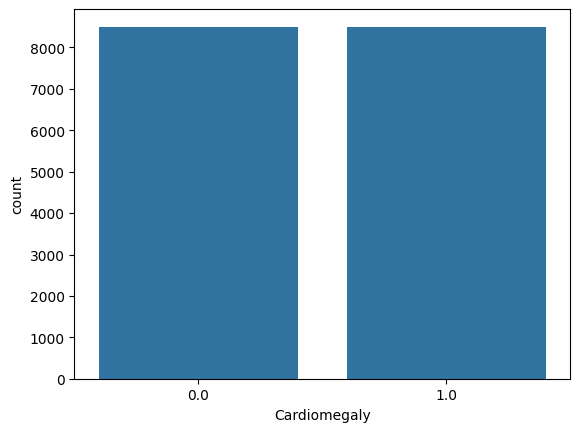

In [61]:
sns.countplot(df_2, x='Cardiomegaly')

## Prepare Test DataFrame

In [62]:
df_test = pd.read_csv("/content/test_submission.csv")
print(len(df_test))
df_test = df_test.rename(columns={"filename": "image_name"})
df_test = pd.merge(df_images, df_test, on='image_name', how='inner')
df_test

2506


,image_name,0,1,2,3,4,5,6,7,8,...,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax
0,cxr00912.jpg,0.530452,1.007566,0.994446,0.326152,0.265369,0.404544,0.486098,0.556744,0.289599,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cxr00593.jpg,0.133442,0.537923,0.838629,0.260219,0.541081,0.702404,0.381467,0.050156,0.610509,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,cxr01397.jpg,0.226614,0.743333,1.362265,0.311873,0.179676,0.424489,0.389412,0.207136,0.375863,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,cxr01860.jpg,0.285665,1.445091,0.981095,0.294115,0.178547,0.723464,0.876063,0.237707,0.252407,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,cxr03287.jpg,0.089165,1.206584,0.727821,0.567094,0.282982,1.129750,0.349258,0.334687,0.349788,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2501,cxr04044.jpg,0.039175,0.580658,0.548450,0.132051,0.246383,0.256114,0.495884,0.151241,0.255369,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2502,cxr00191.jpg,0.400671,1.330510,1.173767,0.209276,0.315588,0.283205,0.493971,0.122307,0.663135,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2503,cxr03981.jpg,0.159734,0.914618,1.155981,0.130813,0.045849,0.405936,0.449306,0.671927,0.432675,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2504,cxr00156.jpg,0.288613,0.745333,0.796572,0.192347,0.208318,0.636778,0.190400,0.154660,0.688696,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
df_1_ts = df_test[["image_name", "Atelectasis"]]
df_2_ts = df_test[["image_name", "Cardiomegaly"]]
df_3_ts = df_test[["image_name", "Consolidation"]]
df_4_ts = df_test[["image_name", "Edema"]]

df_5_ts = df_test[["image_name", "Enlarged Cardiomediastinum"]]
df_6_ts = df_test[["image_name", "Fracture"]]
df_7_ts = df_test[["image_name", "Lung Lesion"]]
df_8_ts = df_test[["image_name", "Lung Opacity"]]

df_9_ts = df_test[["image_name", "No Finding"]]
df_10_ts = df_test[["image_name", "Pleural Effusion"]]
df_11_ts = df_test[["image_name", "Pleural Other"]]
df_12_ts = df_test[["image_name", "Pneumonia"]]
df_13_ts = df_test[["image_name", "Pneumothorax"]]

In [64]:
df_1_ts = pd.merge(df_images, df_1_ts, on='image_name', how='inner')
df_2_ts = pd.merge(df_images, df_2_ts, on='image_name', how='inner')
df_3_ts = pd.merge(df_images, df_3_ts, on='image_name', how='inner')
df_4_ts = pd.merge(df_images, df_4_ts, on='image_name', how='inner')
df_5_ts = pd.merge(df_images, df_5_ts, on='image_name', how='inner')

df_6_ts = pd.merge(df_images, df_6_ts, on='image_name', how='inner')
df_7_ts = pd.merge(df_images, df_7_ts, on='image_name', how='inner')
df_8_ts = pd.merge(df_images, df_8_ts, on='image_name', how='inner')
df_9_ts = pd.merge(df_images, df_9_ts, on='image_name', how='inner')
df_10_ts = pd.merge(df_images, df_10_ts, on='image_name', how='inner')


df_11_ts = pd.merge(df_images, df_11_ts, on='image_name', how='inner')
df_12_ts = pd.merge(df_images, df_12_ts, on='image_name', how='inner')
df_13_ts = pd.merge(df_images, df_13_ts, on='image_name', how='inner')

In [65]:
df_1_ts

,image_name,0,1,2,3,4,5,6,7,8,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,Atelectasis
0,cxr00912.jpg,0.530452,1.007566,0.994446,0.326152,0.265369,0.404544,0.486098,0.556744,0.289599,...,0.079834,0.019210,0.278412,0.131504,0.032689,0.023186,0.320815,1.030829,0.611350,NaN
1,cxr00593.jpg,0.133442,0.537923,0.838629,0.260219,0.541081,0.702404,0.381467,0.050156,0.610509,...,0.239582,0.053675,0.317465,0.505669,0.072049,0.057021,0.090470,0.524922,0.295129,NaN
2,cxr01397.jpg,0.226614,0.743333,1.362265,0.311873,0.179676,0.424489,0.389412,0.207136,0.375863,...,0.031205,0.025797,0.305507,0.160362,0.061502,0.066746,0.120446,0.529326,0.212289,NaN
3,cxr01860.jpg,0.285665,1.445091,0.981095,0.294115,0.178547,0.723464,0.876063,0.237707,0.252407,...,0.011603,0.024828,0.357350,0.489789,0.050375,0.156015,0.350388,0.799320,0.946155,NaN
4,cxr03287.jpg,0.089165,1.206584,0.727821,0.567094,0.282982,1.129750,0.349258,0.334687,0.349788,...,0.052763,0.111776,0.603203,0.220767,0.110730,0.303324,0.459729,0.629183,0.074144,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2501,cxr04044.jpg,0.039175,0.580658,0.548450,0.132051,0.246383,0.256114,0.495884,0.151241,0.255369,...,0.023089,0.001692,0.292766,0.369431,0.119376,0.007004,0.190856,0.543316,0.068123,NaN
2502,cxr00191.jpg,0.400671,1.330510,1.173767,0.209276,0.315588,0.283205,0.493971,0.122307,0.663135,...,0.265542,0.009072,0.426329,0.235516,0.117229,0.028673,0.133390,1.488591,0.985286,NaN
2503,cxr03981.jpg,0.159734,0.914618,1.155981,0.130813,0.045849,0.405936,0.449306,0.671927,0.432675,...,0.099772,0.242604,0.334817,0.453395,0.087509,0.106641,0.534820,0.941390,0.064542,NaN
2504,cxr00156.jpg,0.288613,0.745333,0.796572,0.192347,0.208318,0.636778,0.190400,0.154660,0.688696,...,0.209894,0.051364,0.262905,0.484528,0.067461,0.000000,0.261877,0.881331,0.930446,NaN


# Catboost Classification

In [67]:
from re import X
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score


def catboost_classification_pipeline(df, target_columns, df_test):

  # Split Train ans Test
  features = df.drop(['image_name', target_columns], axis=1)
  target = df[target_columns]
  X_train, X_val, Y_train, Y_val = train_test_split(features, target, random_state=3200, test_size=0.20)

  # Defined Model
  model_catboost = CatBoostClassifier(
      iterations=500,
      learning_rate = 0.1,
      depth = 6
  )

  # Scaler data
  scaler = StandardScaler()
  scaler.fit(X_train)
  X_train = scaler.transform(X_train)
  X_val = scaler.transform(X_val)
  print(type(X_train))
  print(type(X_val))
  print(X_train.shape)
  print(X_val.shape)

  # Fit Model
  model_catboost.fit(
      X_train,
      Y_train,
      eval_set = (X_val, Y_val)
  )

  # Evaluation
  y_pred = model_catboost.predict(X_val)
  print(type(y_pred))
  print(y_pred.shape)
  print("Validation F1: ", f1_score(Y_val, y_pred, average='weighted'))


  # Preparation Test Set
  X_test = df_test.drop(['image_name', target_columns], axis=1)
  X_test = scaler.transform(X_test)

  # Prediction
  y_test_prediction = model_catboost.predict(X_test)
  print(y_test_prediction)
  print(type(y_test_prediction))

  # Format to Pandas Series
  df_pred = pd.DataFrame(y_test_prediction)
  df_test_concat = pd.concat([df_test, df_pred], axis=1)
  df_test_concat = df_test_concat.drop(
      columns = [target_columns]
  )

  # Rename last columns
  df_test_concat.columns = [*df_test_concat.columns[:-1], target_columns]
  df_test_concat = df_test_concat[["image_name", target_columns]]

  return df_test_concat


In [68]:
df_1_pred = catboost_classification_pipeline(df_1, "Atelectasis", df_1_ts)
df_2_pred = catboost_classification_pipeline(df_2, "Cardiomegaly", df_2_ts)
df_3_pred = catboost_classification_pipeline(df_3, "Consolidation", df_3_ts)
df_4_pred = catboost_classification_pipeline(df_4, "Edema", df_4_ts)
df_5_pred = catboost_classification_pipeline(df_5, "Enlarged Cardiomediastinum", df_5_ts)
df_6_pred = catboost_classification_pipeline(df_6, "Fracture", df_6_ts)
df_7_pred = catboost_classification_pipeline(df_7, "Lung Lesion", df_7_ts)
df_8_pred = catboost_classification_pipeline(df_8, "Lung Opacity", df_8_ts)
df_9_pred = catboost_classification_pipeline(df_9, "No Finding", df_9_ts)
df_10_pred = catboost_classification_pipeline(df_10, "Pleural Effusion", df_10_ts)
df_11_pred = catboost_classification_pipeline(df_11, "Pleural Other", df_11_ts)
df_12_pred = catboost_classification_pipeline(df_12, "Pneumonia", df_12_ts)
df_13_pred = catboost_classification_pipeline(df_13, "Pneumothorax", df_13_ts)

Streaming output truncated to the last 5000 lines.
127:	learn: 0.1490635	test: 0.2033790	best: 0.2033790 (127)	total: 13.1s	remaining: 38.2s
128:	learn: 0.1479409	test: 0.2022918	best: 0.2022918 (128)	total: 13.3s	remaining: 38.1s
129:	learn: 0.1467338	test: 0.2013265	best: 0.2013265 (129)	total: 13.4s	remaining: 38s
130:	learn: 0.1456994	test: 0.2008379	best: 0.2008379 (130)	total: 13.5s	remaining: 37.9s
131:	learn: 0.1444400	test: 0.1997591	best: 0.1997591 (131)	total: 13.6s	remaining: 37.8s
132:	learn: 0.1434842	test: 0.1993562	best: 0.1993562 (132)	total: 13.7s	remaining: 37.7s
133:	learn: 0.1424501	test: 0.1985497	best: 0.1985497 (133)	total: 13.8s	remaining: 37.6s
134:	learn: 0.1411901	test: 0.1977615	best: 0.1977615 (134)	total: 13.9s	remaining: 37.5s
135:	learn: 0.1402344	test: 0.1972210	best: 0.1972210 (135)	total: 14s	remaining: 37.3s
136:	learn: 0.1392130	test: 0.1964261	best: 0.1964261 (136)	total: 14.1s	remaining: 37.2s
137:	learn: 0.1381785	test: 0.1955963	best: 0.1955963

In [69]:
df_1_pred

,image_name,Atelectasis
0,cxr00912.jpg,0.0
1,cxr00593.jpg,0.0
2,cxr01397.jpg,0.0
3,cxr01860.jpg,0.0
4,cxr03287.jpg,0.0
...,...,...
2501,cxr04044.jpg,0.0
2502,cxr00191.jpg,0.0
2503,cxr03981.jpg,0.0
2504,cxr00156.jpg,0.0


In [70]:
df_2_pred

,image_name,Cardiomegaly
0,cxr00912.jpg,0.0
1,cxr00593.jpg,0.0
2,cxr01397.jpg,1.0
3,cxr01860.jpg,0.0
4,cxr03287.jpg,0.0
...,...,...
2501,cxr04044.jpg,0.0
2502,cxr00191.jpg,0.0
2503,cxr03981.jpg,0.0
2504,cxr00156.jpg,1.0


# Prepare for Submission

In [71]:
df_submission_pred = pd.merge(df_1_pred, df_2_pred, on='image_name', how='inner')
df_submission_pred = pd.merge(df_submission_pred, df_3_pred, on='image_name', how='inner')
df_submission_pred = pd.merge(df_submission_pred, df_4_pred, on='image_name', how='inner')
df_submission_pred = pd.merge(df_submission_pred, df_5_pred, on='image_name', how='inner')
df_submission_pred = pd.merge(df_submission_pred, df_6_pred, on='image_name', how='inner')

df_submission_pred = pd.merge(df_submission_pred, df_7_pred, on='image_name', how='inner')
df_submission_pred = pd.merge(df_submission_pred, df_8_pred, on='image_name', how='inner')
df_submission_pred = pd.merge(df_submission_pred, df_9_pred, on='image_name', how='inner')
df_submission_pred = pd.merge(df_submission_pred, df_10_pred, on='image_name', how='inner')
df_submission_pred = pd.merge(df_submission_pred, df_11_pred, on='image_name', how='inner')

df_submission_pred = pd.merge(df_submission_pred, df_12_pred, on='image_name', how='inner')
df_submission_pred = pd.merge(df_submission_pred, df_13_pred, on='image_name', how='inner')
df_submission_pred

,image_name,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax
0,cxr00912.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,cxr00593.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,cxr01397.jpg,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,cxr01860.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,cxr03287.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2501,cxr04044.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2502,cxr00191.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2503,cxr03981.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2504,cxr00156.jpg,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [73]:
df_submit = pd.read_csv("test_submission.csv")
df_submit

,filename,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax
0,cxr00001.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,cxr00002.jpg,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,cxr00003.jpg,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,cxr00007.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,cxr00008.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2501,cxr08417.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2502,cxr08428.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2503,cxr09558.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2504,cxr10456.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
df_submission_pred = df_submission_pred.rename(columns={"image_name": "filename"})
df_submission_pred

,filename,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax
0,cxr00912.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,cxr00593.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,cxr01397.jpg,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,cxr01860.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,cxr03287.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2501,cxr04044.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2502,cxr00191.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2503,cxr03981.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2504,cxr00156.jpg,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [75]:
df_submission_pred.to_csv("exp1_chase_hack.csv")